# Snow Conditions Exploratory Data Analysis

This notebook explores historical snow data from ski resorts, including snowfall totals and snow depth at base and summit elevations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DB_PATH = Path('/media/kwierman/Data/powderpipeline/powderpipeline.sqlite')

resorts_df = pd.read_sql('SELECT * FROM skiresort', f'sqlite:///{DB_PATH}')
snow_df = pd.read_sql('SELECT * FROM snow', f'sqlite:///{DB_PATH}')

print(f"Ski Resorts: {len(resorts_df)} records")
print(f"Snow Records: {len(snow_df)} records")
print(f"\nResort columns: {list(resorts_df.columns)}")
print(f"Snow columns: {list(snow_df.columns)}")

Ski Resorts: 800 records
Snow Records: 1204 records

Resort columns: ['id', 'resort_name', 'pass_affiliation', 'latitude', 'longitude', 'base_elevation', 'summit_elevation']
Snow columns: ['id', 'resort_id', 'record_date', 'base_snowfall_inches', 'base_snow_depth_inches', 'summit_snowfall_inches', 'summit_snow_depth_inches']


In [2]:
# Merge snow data with resort information
df = snow_df.merge(resorts_df[['id', 'resort_name', 'pass_affiliation']], 
                   left_on='resort_id', right_on='id', how='left', suffixes=('', '_resort'))
df = df.drop(columns=['id_resort'])

# Convert record_date to datetime
df['record_date'] = pd.to_datetime(df['record_date'])
df['year'] = df['record_date'].dt.year
df['month'] = df['record_date'].dt.month
df['day_of_year'] = df['record_date'].dt.dayofyear

# Create snow season (Oct 1 - Apr 30)
def get_snow_season(row):
    if row['month'] >= 10:
        return f"{row['year']}-{row['year'] + 1}"
    else:
        return f"{row['year'] - 1}-{row['year']}"

df['snow_season'] = df.apply(get_snow_season, axis=1)

df.head()

,id,resort_id,record_date,base_snowfall_inches,base_snow_depth_inches,summit_snowfall_inches,summit_snow_depth_inches,resort_name,pass_affiliation,year,month,day_of_year,snow_season
0,bd34e338162f480dab570d89dbaa113d,9933116923a242849a9834247a4b41dd,2016-09-30,0.0,0.0,0.0,0.0,Snowshoe Mountain Ski Resort,Epic,2016,9,274,2015-2016
1,5688766a51fd4973bb631015f7ac30f1,9933116923a242849a9834247a4b41dd,2016-10-01,0.0,0.0,0.0,0.0,Snowshoe Mountain Ski Resort,Epic,2016,10,275,2016-2017
2,97cd7f72a6fb4ae491c457afdadd15a1,9933116923a242849a9834247a4b41dd,2016-10-02,0.0,0.0,0.0,0.0,Snowshoe Mountain Ski Resort,Epic,2016,10,276,2016-2017
3,d131e0db27264561b33864b57540739e,9933116923a242849a9834247a4b41dd,2016-10-03,0.0,0.0,0.0,0.0,Snowshoe Mountain Ski Resort,Epic,2016,10,277,2016-2017
4,f7aff47676fe4d8d96280f8b7776d3a2,9933116923a242849a9834247a4b41dd,2016-10-04,0.0,0.0,0.0,0.0,Snowshoe Mountain Ski Resort,Epic,2016,10,278,2016-2017


## Data Overview

In [3]:
print("=" * 60)
print("SNOW DATA SUMMARY")
print("=" * 60)

print(f"\nDate Range: {df['record_date'].min().date()} to {df['record_date'].max().date()}")
print(f"Unique Resorts: {df['resort_id'].nunique()}")
print(f"Snow Seasons: {sorted(df['snow_season'].unique())}")

print("\nMissing Data Summary:")
print(df[['base_snowfall_inches', 'base_snow_depth_inches', 
          'summit_snowfall_inches', 'summit_snow_depth_inches']].isnull().sum())

SNOW DATA SUMMARY

Date Range: 2016-01-01 to 2020-12-30
Unique Resorts: 1
Snow Seasons: ['2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021']

Missing Data Summary:
base_snowfall_inches        0
base_snow_depth_inches      0
summit_snowfall_inches      0
summit_snow_depth_inches    0
dtype: int64


In [4]:
df[['base_snowfall_inches', 'base_snow_depth_inches', 
    'summit_snowfall_inches', 'summit_snow_depth_inches']].describe()

,base_snowfall_inches,base_snow_depth_inches,summit_snowfall_inches,summit_snow_depth_inches
count,1204.000000,1204.000000,1204.000000,1204.000000
mean,0.209460,1.219493,0.209460,1.219493
std,0.654311,2.231930,0.654311,2.231930
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.390000,0.000000,0.390000
75%,0.060000,1.570000,0.060000,1.570000
max,7.830000,16.140000,7.830000,16.140000


## Distribution Analysis

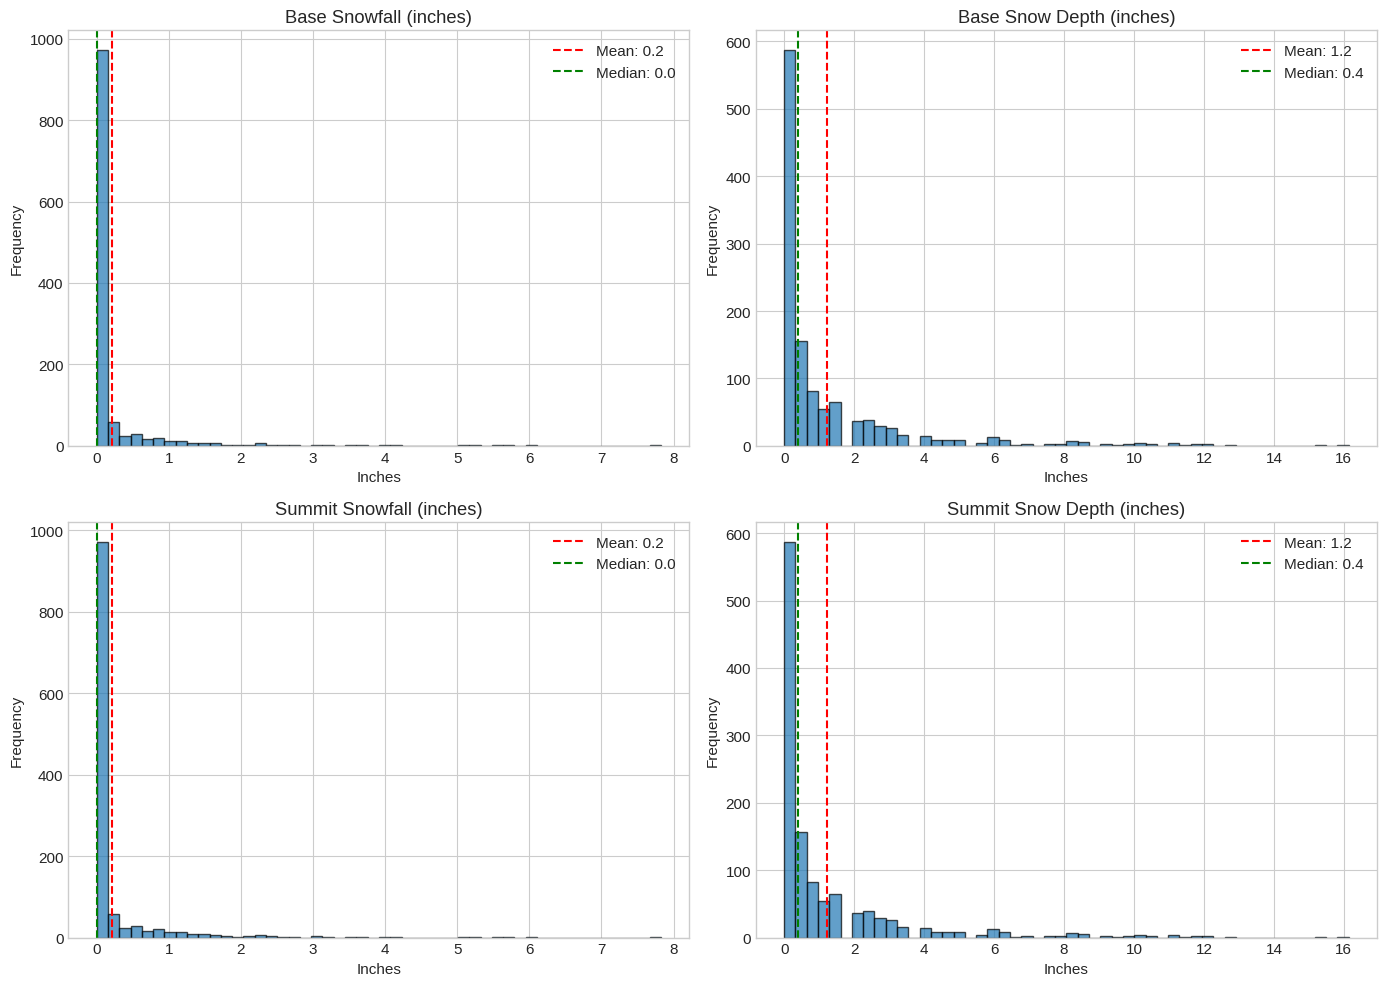

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

columns = ['base_snowfall_inches', 'base_snow_depth_inches', 
           'summit_snowfall_inches', 'summit_snow_depth_inches']
titles = ['Base Snowfall (inches)', 'Base Snow Depth (inches)',
          'Summit Snowfall (inches)', 'Summit Snow Depth (inches)']

for ax, col, title in zip(axes.flatten(), columns, titles):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Inches')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.1f}')
    ax.legend()

plt.tight_layout()
plt.savefig('snow_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Seasonal Trends

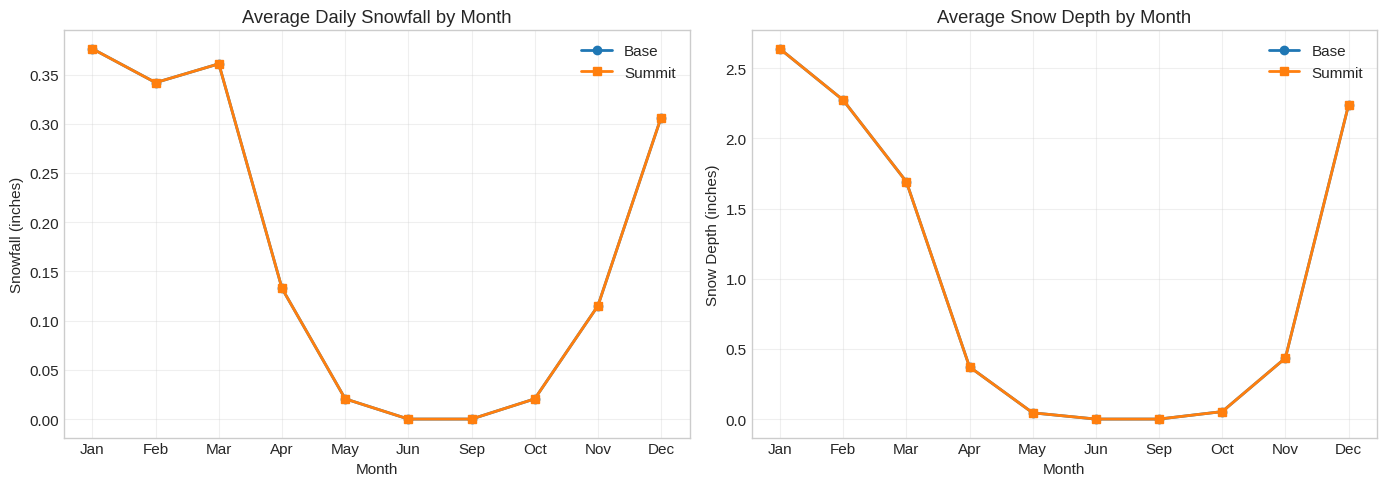

In [6]:
# Aggregate by month across all years
monthly_avg = df.groupby('month').agg({
    'base_snowfall_inches': 'mean',
    'base_snow_depth_inches': 'mean',
    'summit_snowfall_inches': 'mean',
    'summit_snow_depth_inches': 'mean'
}).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x - 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Snowfall by month
axes[0].plot(monthly_avg['month_name'], monthly_avg['base_snowfall_inches'], 
             marker='o', label='Base', linewidth=2)
axes[0].plot(monthly_avg['month_name'], monthly_avg['summit_snowfall_inches'], 
             marker='s', label='Summit', linewidth=2)
axes[0].set_title('Average Daily Snowfall by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Snowfall (inches)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Snow Depth by month
axes[1].plot(monthly_avg['month_name'], monthly_avg['base_snow_depth_inches'], 
             marker='o', label='Base', linewidth=2)
axes[1].plot(monthly_avg['month_name'], monthly_avg['summit_snow_depth_inches'], 
             marker='s', label='Summit', linewidth=2)
axes[1].set_title('Average Snow Depth by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Snow Depth (inches)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('snow_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Year-over-Year Comparison

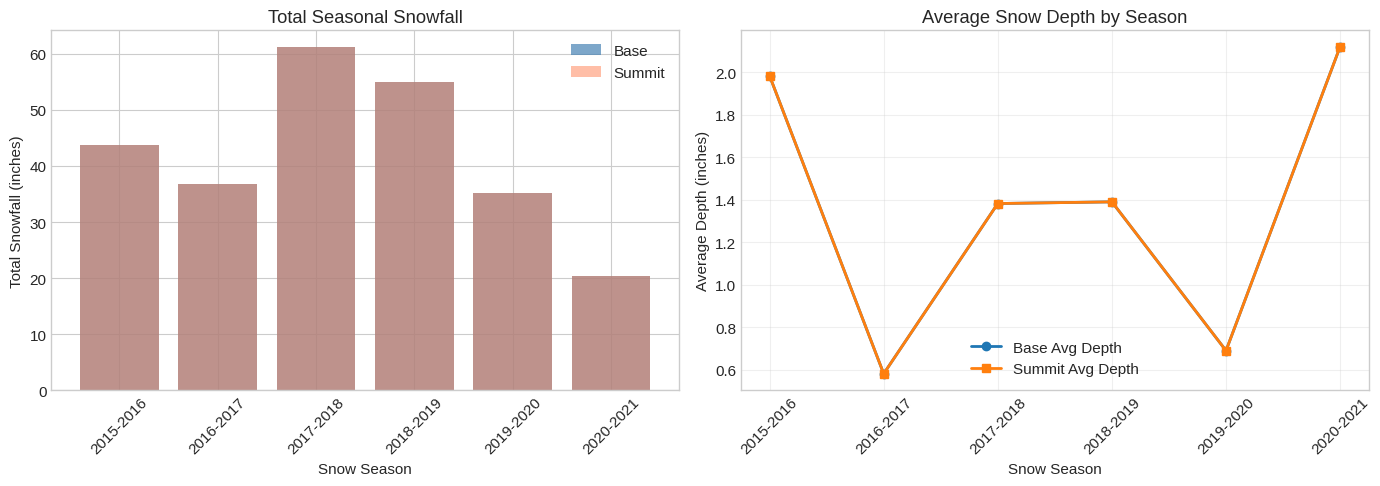


Seasonal Statistics:
  snow_season  base_snowfall_inches_sum  summit_snowfall_inches_sum  \
0   2015-2016                     43.83                       43.83   
1   2016-2017                     36.76                       36.76   
2   2017-2018                     61.16                       61.16   
3   2018-2019                     54.99                       54.99   
4   2019-2020                     35.11                       35.11   
5   2020-2021                     20.34                       20.34   

   base_snow_depth_inches_mean  summit_snow_depth_inches_mean  
0                     1.983709                       1.983709  
1                     0.581235                       0.581235  
2                     1.382459                       1.382459  
3                     1.390328                       1.390328  
4                     0.689871                       0.689871  
5                     2.120889                       2.120889  


In [7]:
# Aggregate by season
seasonal_stats = df.groupby('snow_season').agg({
    'base_snowfall_inches': ['mean', 'sum', 'std'],
    'summit_snowfall_inches': ['mean', 'sum', 'std'],
    'base_snow_depth_inches': 'mean',
    'summit_snow_depth_inches': 'mean'
}).reset_index()

seasonal_stats.columns = ['_'.join(col).strip('_') for col in seasonal_stats.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total snowfall by season
x = seasonal_stats['snow_season']
axes[0].bar(x, seasonal_stats['base_snowfall_inches_sum'], alpha=0.7, label='Base', color='steelblue')
axes[0].bar(x, seasonal_stats['summit_snowfall_inches_sum'], alpha=0.5, label='Summit', color='coral')
axes[0].set_title('Total Seasonal Snowfall')
axes[0].set_xlabel('Snow Season')
axes[0].set_ylabel('Total Snowfall (inches)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Average snow depth by season
axes[1].plot(x, seasonal_stats['base_snow_depth_inches_mean'], marker='o', label='Base Avg Depth', linewidth=2)
axes[1].plot(x, seasonal_stats['summit_snow_depth_inches_mean'], marker='s', label='Summit Avg Depth', linewidth=2)
axes[1].set_title('Average Snow Depth by Season')
axes[1].set_xlabel('Snow Season')
axes[1].set_ylabel('Average Depth (inches)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('snow_seasonal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSeasonal Statistics:")
print(seasonal_stats[['snow_season', 'base_snowfall_inches_sum', 'summit_snowfall_inches_sum',
                       'base_snow_depth_inches_mean', 'summit_snow_depth_inches_mean']])

## Resort-Level Analysis

In [8]:
# Top resorts by average snowfall
resort_avg = df.groupby('resort_name').agg({
    'base_snowfall_inches': 'mean',
    'summit_snowfall_inches': 'mean',
    'base_snow_depth_inches': 'mean',
    'summit_snow_depth_inches': 'mean'
}).round(2)

print("Top 10 Resorts by Average Daily Snowfall (Summit):")
print(resort_avg.sort_values('summit_snowfall_inches', ascending=False).head(10))

print("\n\nTop 10 Resorts by Average Snow Depth (Summit):")
print(resort_avg.sort_values('summit_snow_depth_inches', ascending=False).head(10))

Top 10 Resorts by Average Daily Snowfall (Summit):
                              base_snowfall_inches  summit_snowfall_inches  \
resort_name                                                                  
Snowshoe Mountain Ski Resort                  0.21                    0.21   

                              base_snow_depth_inches  summit_snow_depth_inches  
resort_name                                                                     
Snowshoe Mountain Ski Resort                    1.22                      1.22  


Top 10 Resorts by Average Snow Depth (Summit):
                              base_snowfall_inches  summit_snowfall_inches  \
resort_name                                                                  
Snowshoe Mountain Ski Resort                  0.21                    0.21   

                              base_snow_depth_inches  summit_snow_depth_inches  
resort_name                                                                     
Snowshoe Mountain Ski Res

In [9]:
# Compare resorts by pass affiliation
pass_comparison = df.groupby('pass_affiliation').agg({
    'base_snowfall_inches': 'mean',
    'summit_snowfall_inches': 'mean',
    'base_snow_depth_inches': 'mean',
    'summit_snow_depth_inches': 'mean'
}).round(2)

print("Average Snow Conditions by Pass Affiliation:")
print(pass_comparison.sort_values('summit_snowfall_inches', ascending=False))

Average Snow Conditions by Pass Affiliation:
                  base_snowfall_inches  summit_snowfall_inches  \
pass_affiliation                                                 
Epic                              0.21                    0.21   

                  base_snow_depth_inches  summit_snow_depth_inches  
pass_affiliation                                                    
Epic                                1.22                      1.22  


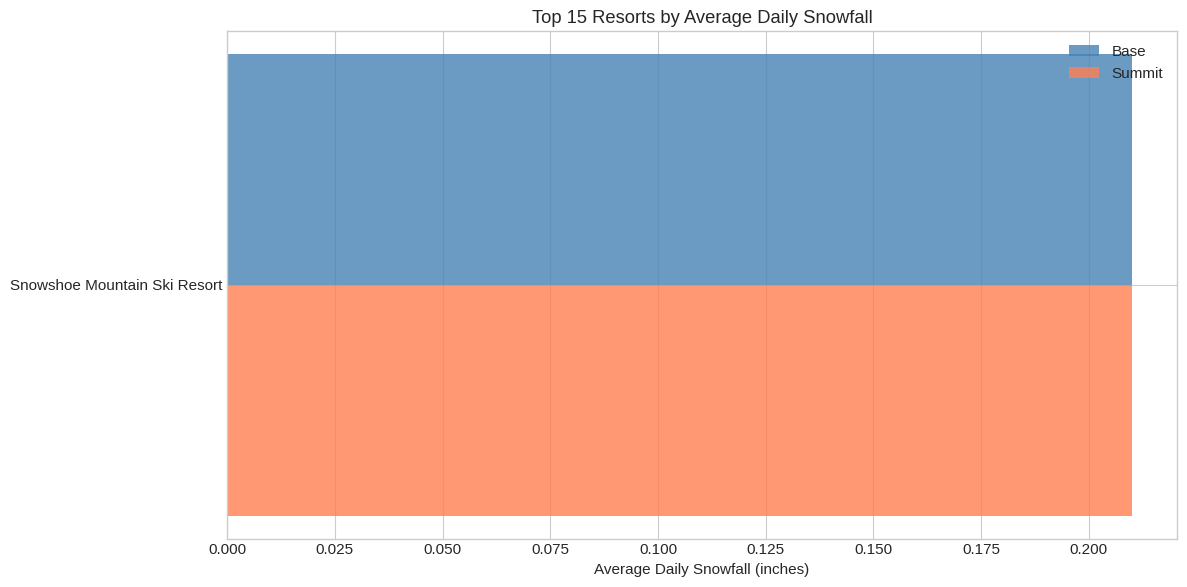

In [10]:
# Visualize top resorts
top_resorts = resort_avg.sort_values('summit_snowfall_inches', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top_resorts))
width = 0.35

ax.barh([i - width/2 for i in x], top_resorts['base_snowfall_inches'], width, 
        label='Base', color='steelblue', alpha=0.8)
ax.barh([i + width/2 for i in x], top_resorts['summit_snowfall_inches'], width, 
        label='Summit', color='coral', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top_resorts.index)
ax.set_xlabel('Average Daily Snowfall (inches)')
ax.set_title('Top 15 Resorts by Average Daily Snowfall')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('snow_top_resorts.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Analysis

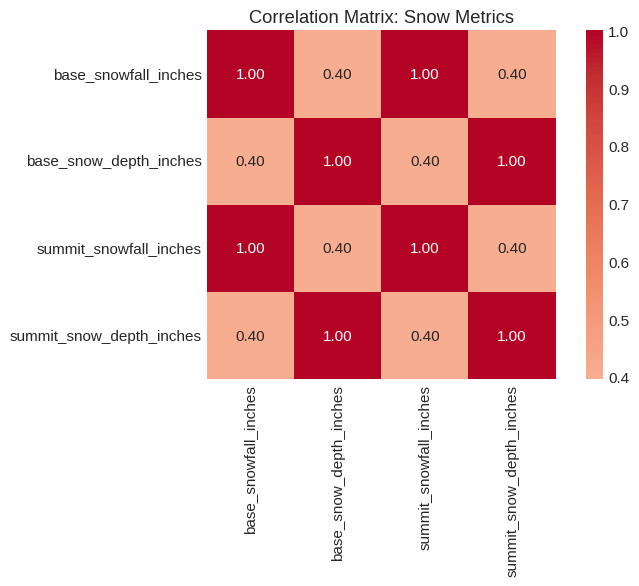


Key Correlations:
Base Snowfall vs Summit Snowfall: 1.000
Base Depth vs Summit Depth: 1.000
Base Snowfall vs Base Depth: 0.396


In [11]:
# Correlation matrix
corr_cols = ['base_snowfall_inches', 'base_snow_depth_inches', 
             'summit_snowfall_inches', 'summit_snow_depth_inches']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix: Snow Metrics')

plt.tight_layout()
plt.savefig('snow_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Correlations:")
print(f"Base Snowfall vs Summit Snowfall: {corr_matrix.loc['base_snowfall_inches', 'summit_snowfall_inches']:.3f}")
print(f"Base Depth vs Summit Depth: {corr_matrix.loc['base_snow_depth_inches', 'summit_snow_depth_inches']:.3f}")
print(f"Base Snowfall vs Base Depth: {corr_matrix.loc['base_snowfall_inches', 'base_snow_depth_inches']:.3f}")

## Elevation Impact Analysis

In [12]:
# Get elevation data for resorts
resort_elevations = pd.read_sql('SELECT id, resort_name, base_elevation, summit_elevation FROM skiresort', 
                                 f'sqlite:///{DB_PATH}')

# Merge elevations with snow data
df_elev = df.merge(resort_elevations[['id', 'base_elevation', 'summit_elevation']], 
                    left_on='resort_id', right_on='id', how='left', suffixes=('', '_elev'))

# Calculate elevation difference
df_elev['elevation_diff'] = df_elev['summit_elevation'] - df_elev['base_elevation']

# Correlation with elevation
print("Correlation with Base Elevation:")
print(f"  Base Elevation vs Base Snowfall: {df_elev['base_elevation'].corr(df_elev['base_snowfall_inches']):.3f}")
print(f"  Base Elevation vs Summit Snowfall: {df_elev['base_elevation'].corr(df_elev['summit_snowfall_inches']):.3f}")

print("\nCorrelation with Elevation Difference:")
print(f"  Elevation Diff vs Snowfall Diff: {(df_elev['summit_snowfall_inches'] - df_elev['base_snowfall_inches']).corr(df_elev['elevation_diff']):.3f}")

Correlation with Base Elevation:
  Base Elevation vs Base Snowfall: nan
  Base Elevation vs Summit Snowfall: nan

Correlation with Elevation Difference:
  Elevation Diff vs Snowfall Diff: nan


/home/kwierman/Desktop/Projects/PowderPipeline/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/kwierman/Desktop/Projects/PowderPipeline/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


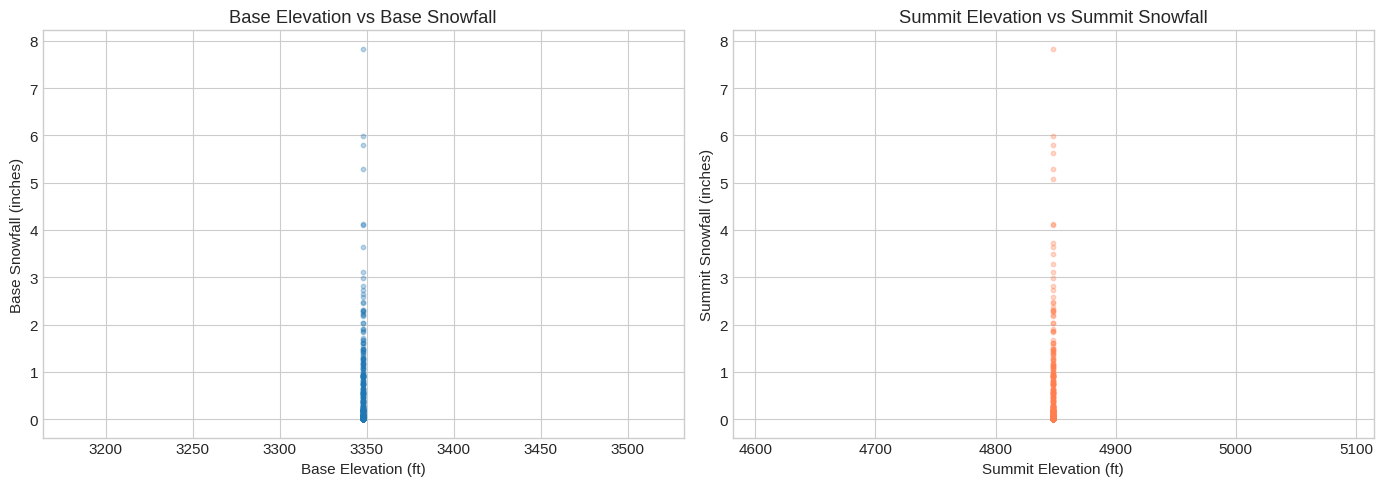

In [13]:
# Scatter plot: Elevation vs Snowfall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base elevation vs base snowfall
sample = df_elev.dropna(subset=['base_elevation', 'base_snowfall_inches']).sample(min(1000, len(df_elev)))
axes[0].scatter(sample['base_elevation'], sample['base_snowfall_inches'], alpha=0.3, s=10)
axes[0].set_xlabel('Base Elevation (ft)')
axes[0].set_ylabel('Base Snowfall (inches)')
axes[0].set_title('Base Elevation vs Base Snowfall')

# Summit elevation vs summit snowfall
sample = df_elev.dropna(subset=['summit_elevation', 'summit_snowfall_inches']).sample(min(1000, len(df_elev)))
axes[1].scatter(sample['summit_elevation'], sample['summit_snowfall_inches'], alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Summit Elevation (ft)')
axes[1].set_ylabel('Summit Snowfall (inches)')
axes[1].set_title('Summit Elevation vs Summit Snowfall')

plt.tight_layout()
plt.savefig('snow_elevation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Daily Variability

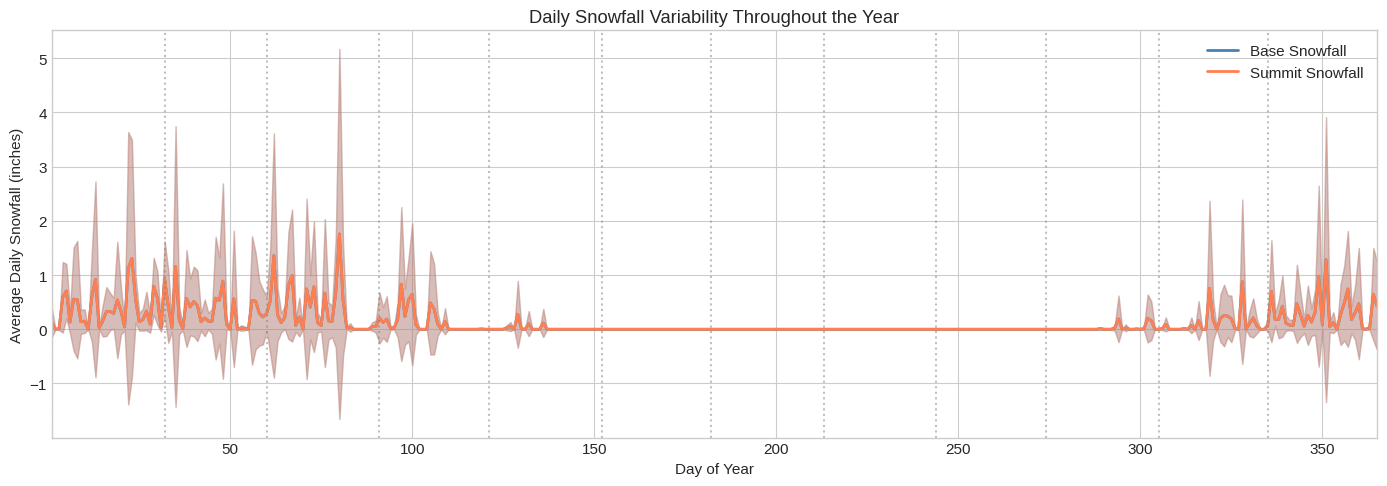

In [14]:
# Day of year analysis
doy_stats = df.groupby('day_of_year').agg({
    'base_snowfall_inches': ['mean', 'std'],
    'summit_snowfall_inches': ['mean', 'std']
}).reset_index()
doy_stats.columns = ['day_of_year', 'base_mean', 'base_std', 'summit_mean', 'summit_std']

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(doy_stats['day_of_year'], doy_stats['base_mean'] - doy_stats['base_std'],
                doy_stats['base_mean'] + doy_stats['base_std'], alpha=0.3, color='steelblue')
ax.plot(doy_stats['day_of_year'], doy_stats['base_mean'], label='Base Snowfall', linewidth=2, color='steelblue')

ax.fill_between(doy_stats['day_of_year'], doy_stats['summit_mean'] - doy_stats['summit_std'],
                doy_stats['summit_mean'] + doy_stats['summit_std'], alpha=0.3, color='coral')
ax.plot(doy_stats['day_of_year'], doy_stats['summit_mean'], label='Summit Snowfall', linewidth=2, color='coral')

# Add month boundaries
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for start, label in zip(month_starts, month_labels):
    ax.axvline(start, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Day of Year')
ax.set_ylabel('Average Daily Snowfall (inches)')
ax.set_title('Daily Snowfall Variability Throughout the Year')
ax.legend()
ax.set_xlim(1, 365)

plt.tight_layout()
plt.savefig('snow_daily_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings Summary

In [15]:
print("=" * 70)
print("SNOW CONDITIONS ANALYSIS: KEY FINDINGS")
print("=" * 70)

# Overall statistics
print("\n1. OVERALL STATISTICS:")
print("-" * 50)
print(f"   Total Records: {len(df):,}")
print(f"   Date Range: {df['record_date'].min().date()} to {df['record_date'].max().date()}")
print(f"   Unique Resorts: {df['resort_id'].nunique()}")

# Snowfall stats
print("\n2. SNOWFALL STATISTICS:")
print("-" * 50)
print(f"   Average Daily Base Snowfall: {df['base_snowfall_inches'].mean():.2f} inches")
print(f"   Average Daily Summit Snowfall: {df['summit_snowfall_inches'].mean():.2f} inches")
print(f"   Max Daily Base Snowfall: {df['base_snowfall_inches'].max():.2f} inches")
print(f"   Max Daily Summit Snowfall: {df['summit_snowfall_inches'].max():.2f} inches")

# Snow depth stats
print("\n3. SNOW DEPTH STATISTICS:")
print("-" * 50)
print(f"   Average Base Snow Depth: {df['base_snow_depth_inches'].mean():.2f} inches")
print(f"   Average Summit Snow Depth: {df['summit_snow_depth_inches'].mean():.2f} inches")
print(f"   Max Base Snow Depth: {df['base_snow_depth_inches'].max():.2f} inches")
print(f"   Max Summit Snow Depth: {df['summit_snow_depth_inches'].max():.2f} inches")

# Top performing resorts
print("\n4. TOP 5 RESORTS BY AVERAGE SNOWFALL:")
print("-" * 50)
top5 = resort_avg.sort_values('summit_snowfall_inches', ascending=False).head(5)
for i, (resort, row) in enumerate(top5.iterrows(), 1):
    print(f"   {i}. {resort}: {row['summit_snowfall_inches']:.2f} in/day (summit avg)")

# Pass affiliation comparison
print("\n5. SNOW CONDITIONS BY PASS AFFILIATION:")
print("-" * 50)
for affil, row in pass_comparison.sort_values('summit_snowfall_inches', ascending=False).iterrows():
    print(f"   {affil}: {row['summit_snowfall_inches']:.2f} in/day avg snowfall")

SNOW CONDITIONS ANALYSIS: KEY FINDINGS

1. OVERALL STATISTICS:
--------------------------------------------------
   Total Records: 1,204
   Date Range: 2016-01-01 to 2020-12-30
   Unique Resorts: 1

2. SNOWFALL STATISTICS:
--------------------------------------------------
   Average Daily Base Snowfall: 0.21 inches
   Average Daily Summit Snowfall: 0.21 inches
   Max Daily Base Snowfall: 7.83 inches
   Max Daily Summit Snowfall: 7.83 inches

3. SNOW DEPTH STATISTICS:
--------------------------------------------------
   Average Base Snow Depth: 1.22 inches
   Average Summit Snow Depth: 1.22 inches
   Max Base Snow Depth: 16.14 inches
   Max Summit Snow Depth: 16.14 inches

4. TOP 5 RESORTS BY AVERAGE SNOWFALL:
--------------------------------------------------
   1. Snowshoe Mountain Ski Resort: 0.21 in/day (summit avg)

5. SNOW CONDITIONS BY PASS AFFILIATION:
--------------------------------------------------
   Epic: 0.21 in/day avg snowfall


In [16]:
resorts_df['base_elevation'].max()

np.float64(10800.0)